## Customer Segmentation Using K-Means Clustering and PCA Visualization

# Project Description

This project focuses on customer behavioral segmentation using unsupervised machine learning techniques. The objective of the project is to identify hidden behavioral patterns and group similar users based on interests, activities, and social behavior indicators.

The dataset contains multiple behavioral features related to sports, music, shopping habits, social interaction, and lifestyle preferences. Since the dataset does not contain predefined target labels, clustering algorithms such as Hierarchical Clustering and KMeans were used to discover meaningful customer segments.

The project includes data preprocessing, feature standardization, clustering analysis, PCA visualization, and cluster profiling to better understand user behavior patterns and customer group characteristics.

## Data Loading and Cleaning

In [ ]:
# Importing Necessary Libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [2]:
# Loading the Dataset
df = pd.read_csv("Clustering_Marketing.csv")
print("Displaying the first few rows of the dataset : ",df.head())

Displaying the first few rows of the dataset :     gradyear gender     age  NumberOffriends  basketball  football  soccer  \
0      2007    NaN     NaN                0           0         0       0   
1      2007      F   17.41               49           0         0       1   
2      2007      F  17.511               41           0         0       0   
3      2006      F     NaN               36           0         0       0   
4      2008      F  16.657                1           0         0       0   

   softball  volleyball  swimming  ...  blonde  mall  shopping  clothes  \
0         0           0         0  ...       0     0         0        0   
1         0           0         1  ...       0     0         0        0   
2         0           0         0  ...       0     1         0        0   
3         0           0         0  ...       0     0         0        0   
4         0           0         1  ...       0     0         0        3   

   hollister  abercrombie  die  death 

In [3]:
# Display dataset dimensions and first few rows
print("Dataset Shape (rows & columns):", df.shape)

Dataset Shape (rows & columns): (15000, 40)


In [4]:
# Information about the dataset
print("Information about the dataset : ",df.info())

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   gradyear         15000 non-null  int64
 1   gender           13663 non-null  str  
 2   age              12504 non-null  str  
 3   NumberOffriends  15000 non-null  int64
 4   basketball       15000 non-null  int64
 5   football         15000 non-null  int64
 6   soccer           15000 non-null  int64
 7   softball         15000 non-null  int64
 8   volleyball       15000 non-null  int64
 9   swimming         15000 non-null  int64
 10  cheerleading     15000 non-null  int64
 11  baseball         15000 non-null  int64
 12  tennis           15000 non-null  int64
 13  sports           15000 non-null  int64
 14  cute             15000 non-null  int64
 15  sex              15000 non-null  int64
 16  sexy             15000 non-null  int64
 17  hot              15000 non-null  int64
 18  kissed           

In [5]:
# Descriptive Statistics of the dataset
print("Descriptive statistics of the dataset : ",df.describe())

Descriptive statistics of the dataset :             gradyear  NumberOffriends    basketball      football       soccer  \
count  15000.000000     15000.000000  15000.000000  15000.000000  15000.00000   
mean    2007.496933        29.834533      0.267000      0.255467      0.22200   
std        1.116516        35.386649      0.788851      0.702260      0.92042   
min     2006.000000         0.000000      0.000000      0.000000      0.00000   
25%     2006.000000         3.000000      0.000000      0.000000      0.00000   
50%     2008.000000        20.000000      0.000000      0.000000      0.00000   
75%     2008.000000        44.000000      0.000000      0.000000      0.00000   
max     2009.000000       605.000000     22.000000      9.000000     22.00000   

           softball    volleyball      swimming  cheerleading      baseball  \
count  15000.000000  15000.000000  15000.000000  15000.000000  15000.000000   
mean       0.159667      0.142933      0.135000      0.105133      0.10

In [6]:
#  Checking for missing values in the dataset
print("Checking for missing values in the dataset : ",df.isnull().sum())

Checking for missing values in the dataset :  gradyear              0
gender             1337
age                2496
NumberOffriends       0
basketball            0
football              0
soccer                0
softball              0
volleyball            0
swimming              0
cheerleading          0
baseball              0
tennis                0
sports                0
cute                  0
sex                   0
sexy                  0
hot                   0
kissed                0
dance                 0
band                  0
marching              0
music                 0
rock                  0
god                   0
church                0
jesus                 0
bible                 0
hair                  0
dress                 0
blonde                0
mall                  0
shopping              0
clothes               0
hollister             0
abercrombie           0
die                   0
death                 0
drunk                 0
drugs             

In [7]:
# Checking for duplicates in the dataset
print("Checking for duplicates in the dataset : ",df.duplicated().sum())

Checking for duplicates in the dataset :  266


In [8]:
duplicates = df[df.duplicated()]
duplicates.head()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
146,2006,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
272,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
419,2008,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
532,2008,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
638,2006,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
# Dropping duplicates value from the dataset
df = df.drop_duplicates()
print("After dropping duplicates the dataset shape : ",df.shape)

After dropping duplicates the dataset shape :  (14734, 40)


In [10]:
# Changing the data type of age to numeric
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Fill numeric missing values
df["age"] = df["age"].fillna(df["age"].median())

# keep realistic student age range
df = df[(df["age"] >= 13) & (df["age"] <= 20)]

Age values were restricted to the range of 13–20 years because the dataset represents teenage and young student social behavior. Values outside this range were considered unrealistic or inconsistent with the target population and were removed to improve data quality and clustering reliability.

In [11]:
# Checking the number of unique values in each column
df.nunique()

gradyear              4
gender                2
age                1674
NumberOffriends     236
basketball           13
football             10
soccer               17
softball             16
volleyball           13
swimming             11
cheerleading          9
baseball             14
tennis               15
sports               10
cute                 14
sex                  21
sexy                 12
hot                   9
kissed               10
dance                19
band                 21
marching             10
music                23
rock                 16
god                  25
church               12
jesus                16
bible                 9
hair                 17
dress                 8
blonde               12
mall                 12
shopping             10
clothes               9
hollister             8
abercrombie           7
die                  14
death                11
drunk                 9
drugs                 9
dtype: int64

In [12]:
#  Dropping the columns that are not relevant for clustering
df1 = df.drop(columns=["gender", "gradyear"])

In [13]:
# Shape of the data after dropping
print("Shape of the data after dropping : ",df1.shape)

Shape of the data after dropping :  (14526, 38)


The dataset was first inspected for missing values, duplicate records, and incorrect data types. Duplicate records were removed to avoid repeated customer patterns affecting the clustering process.

The `age` column was converted into numeric format because it was initially stored as an object/string type. Missing age values were handled using median imputation, as the median is less sensitive to extreme values than the mean. After imputation, unrealistic age values were removed by keeping only users between 13 and 20 years old.

The `gender` and `gradyear` columns were removed because the main objective of this project is to cluster customers based on behavioral and interest-based features rather than demographic identifiers.

## Standardize Features

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df1)

In [15]:
df_final = pd.DataFrame(X_scaled, columns=df1.columns)
df_final.head()

,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,0.026693,-0.856431,-0.343105,-0.369274,-0.243489,-0.219748,-0.226768,-0.248723,-0.211866,-0.203396,...,-0.041929,-0.373294,-0.497069,-0.317382,-0.203241,-0.18535,-0.307858,-0.262071,-0.220305,-0.176705
1,0.136006,0.522659,-0.343105,-0.369274,0.830908,-0.219748,-0.226768,1.548765,-0.211866,-0.203396,...,-0.041929,-0.373294,-0.497069,-0.317382,-0.203241,-0.18535,-0.307858,-0.262071,2.127564,-0.176705
2,0.232012,0.297501,-0.343105,-0.369274,-0.243489,-0.219748,-0.226768,-0.248723,-0.211866,1.694180,...,-0.041929,1.028947,-0.497069,-0.317382,-0.203241,-0.18535,-0.307858,-0.262071,2.127564,2.662696
3,0.026693,0.156778,-0.343105,-0.369274,-0.243489,-0.219748,-0.226768,-0.248723,-0.211866,-0.203396,...,-0.041929,-0.373294,-0.497069,-0.317382,-0.203241,-0.18535,-0.307858,-0.262071,-0.220305,-0.176705
4,-0.579758,-0.828286,-0.343105,-0.369274,-0.243489,-0.219748,-0.226768,1.548765,-0.211866,-0.203396,...,-0.041929,-0.373294,-0.497069,5.876479,-0.203241,-0.18535,-0.307858,-0.262071,-0.220305,-0.176705


Standardization was applied using `StandardScaler` to bring all numerical features onto the same scale. This step is important because clustering algorithms such as KMeans and hierarchical clustering are distance-based models. Without scaling, features with larger numerical ranges could dominate the distance calculation and negatively affect cluster formation.

## Linkage and Dendrograms

**Complete**

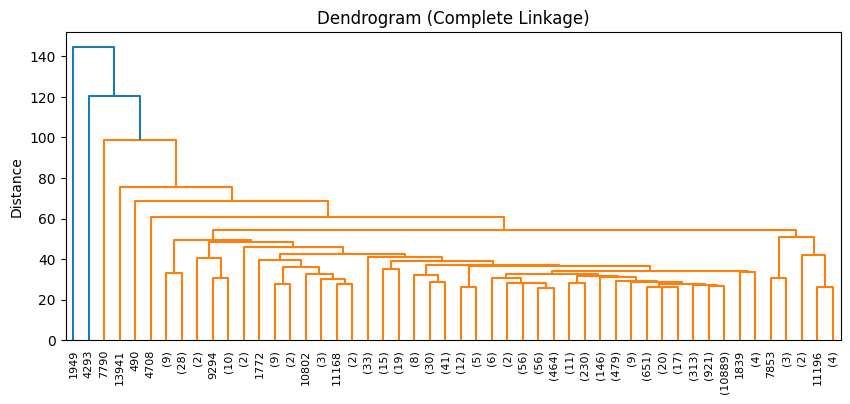

In [16]:
Z_complete = linkage(df_final,method='complete',metric='euclidean')
plt.figure(figsize=(10,4))
dendrogram(Z_complete,truncate_mode='lastp',p=50)
plt.title('Dendrogram (Complete Linkage)')
plt.ylabel('Distance')
plt.show()

**Ward**

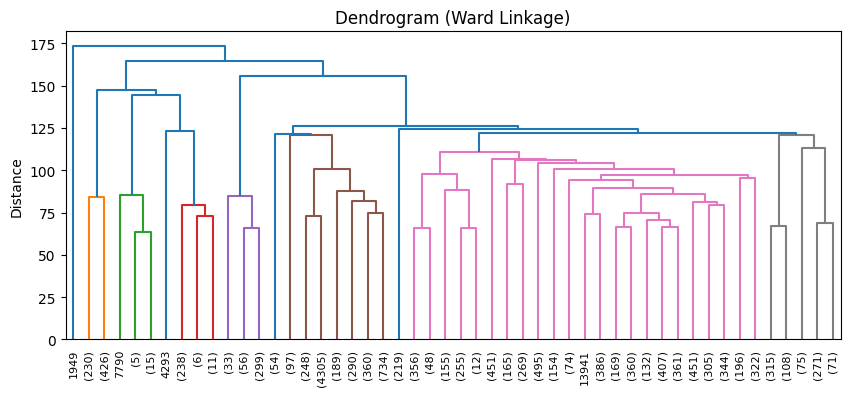

In [17]:
Z_ward = linkage(df_final,method='ward',metric='euclidean')
plt.figure(figsize=(10,4))
dendrogram(Z_ward,truncate_mode='lastp',p=50)
plt.title('Dendrogram (Ward Linkage)')
plt.ylabel('Distance')
plt.show()

## Clustering

**Single**

In [18]:
k = 5

# Build linkage on full dataset (single linkage)
Z = linkage(df_final,method='single',metric='euclidean')
labels_h = fcluster(Z,t=k,criterion='maxclust')

In [19]:
df1['Cluster_Hierarchical_Single'] = labels_h
df1.head()

,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,...,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs,Cluster_Hierarchical_Single
0,17.295,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,17.410,49,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,1
2,17.511,41,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,1,1,1
3,17.295,36,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,16.657,1,0,0,0,0,0,1,0,0,...,0,0,3,0,0,0,0,0,0,1


In [20]:
sil_h = silhouette_score(df_final,labels_h)
sil_h

0.8538776571600494

**Complete**

In [21]:
Z_c = linkage(df_final,method='complete',metric='euclidean')
labels_h = fcluster(Z_c,t=k,criterion='maxclust')

In [22]:
df1['Cluster_Hierarchical_Complete'] = labels_h
df1.head()

,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,...,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs,Cluster_Hierarchical_Single,Cluster_Hierarchical_Complete
0,17.295,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
1,17.410,49,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,1
2,17.511,41,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,1,1,1
3,17.295,36,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
4,16.657,1,0,0,0,0,0,1,0,0,...,0,3,0,0,0,0,0,0,1,1


In [23]:
sil_h = silhouette_score(df_final,labels_h)
sil_h

0.867789027918295

**Average**

In [24]:
Z_a = linkage(df_final,method='average',metric='euclidean')
labels_h = fcluster(Z_a,t=k,criterion='maxclust')

In [25]:
df1['Cluster_Hierarchical_Average'] = labels_h
df1.head()

,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,...,clothes,hollister,abercrombie,die,death,drunk,drugs,Cluster_Hierarchical_Single,Cluster_Hierarchical_Complete,Cluster_Hierarchical_Average
0,17.295,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
1,17.410,49,0,0,1,0,0,1,0,0,...,0,0,0,0,0,1,0,1,1,1
2,17.511,41,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,1,1,1,1
3,17.295,36,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
4,16.657,1,0,0,0,0,0,1,0,0,...,3,0,0,0,0,0,0,1,1,1


In [26]:
sil_h = silhouette_score(df_final,labels_h)
sil_h

0.867789027918295

**Ward**

In [27]:
Z_w = linkage(df_final,method='ward',metric='euclidean')
labels_h = fcluster(Z_w,t=k,criterion='maxclust')

In [28]:
df1['Cluster_Hierarchical_Ward'] = labels_h
df1.head()

,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,...,hollister,abercrombie,die,death,drunk,drugs,Cluster_Hierarchical_Single,Cluster_Hierarchical_Complete,Cluster_Hierarchical_Average,Cluster_Hierarchical_Ward
0,17.295,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,4
1,17.410,49,0,0,1,0,0,1,0,0,...,0,0,0,0,1,0,1,1,1,4
2,17.511,41,0,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,4
3,17.295,36,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,4
4,16.657,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,1,1,4


In [29]:
sil_h = silhouette_score(df_final,labels_h)
sil_h

0.21742141127806425

* Single Linkage Silhouette Score: 0.8538776571600494
* Complete Linkage Silhouette Score: 0.867789027918235
* Average Linkage Silhouette Score: 0.867789027918235
* Ward Linkage Silhouette Score: 0.21742141127806425

## Cluster Evaluation

- Single Linkage achieved a silhouette score of 0.8539.
- Complete Linkage achieved a silhouette score of 0.8678.
- Average Linkage achieved a silhouette score of 0.8678.
- Ward Linkage performed poorly with a silhouette score of 0.2174.

Complete Linkage and Average Linkage achieved the highest silhouette scores.

Although Complete Linkage produced the highest silhouette score, the resulting clusters were highly imbalanced and primarily separated outlier observations instead of meaningful customer groups. Due to the sparse and high-dimensional nature of the behavioral dataset, hierarchical clustering methods struggled to produce balanced and interpretable segments.

KMeans clustering was selected as the final model because it produced more balanced, interpretable, and meaningful customer segments, making it more suitable for customer behavior analysis and segmentation in this project.

## Use Elbow Method

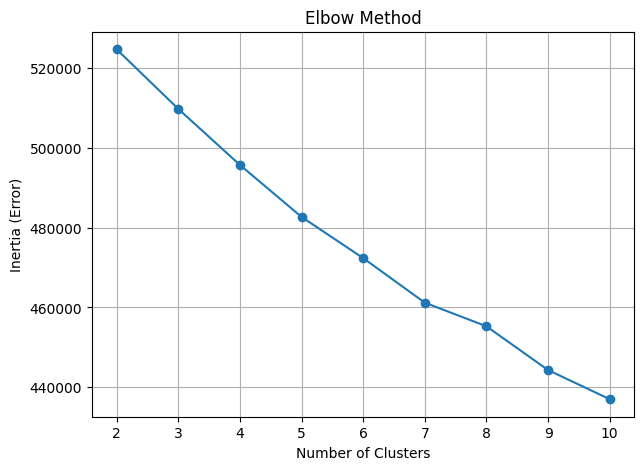

[524631.9962731736, 509709.01883822837, 495670.5796528032, 482655.71527679986, 472342.93765182415, 461182.792075519, 455265.67492268636, 444308.981126409, 437012.2646133584]


In [30]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(df_final)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))

plt.plot(range(2,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (Error)")

plt.grid(True)

plt.show()
print(wcss)

| Algorithm        | Observation                                      |
| ---------------- | ------------------------------------------------ |
| KMeans           | Weak elbow trend observed in WCSS plot           |
| Complete Linkage | High silhouette score with imbalanced clusters   |
| Average Linkage  | High silhouette score with imbalanced clusters   |
| Ward Linkage     | Lower silhouette score and weaker separation     |

The Elbow Method did not show a clear elbow point, indicating weak cluster separation within the dataset. Therefore, hierarchical clustering methods were additionally explored to evaluate alternative clustering structures.

In [31]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

labels_k = kmeans.fit_predict(df_final)

df1["KMeans_Cluster"] = labels_k

In [32]:
print(df1["KMeans_Cluster"].value_counts())

KMeans_Cluster
0    10514
3     3109
4      566
2      336
1        1
Name: count, dtype: int64


One cluster contained a very small number of observations, suggesting potential outlier behavior patterns and imbalance in the clustering structure.

In [33]:
silhouette_avg = silhouette_score(df_final, df1["KMeans_Cluster"])
print("KMeans Silhouette Score:", silhouette_avg)

KMeans Silhouette Score: 0.2768968625123688


The Elbow Method was used to identify a suitable number of clusters for KMeans clustering. The WCSS values decreased as the number of clusters increased, but the elbow point was not very strong. Based on the visual trend and interpretability requirement, `k = 5` was selected for the final KMeans model.

## PCA Visualization

In [34]:
# Initializing PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df_final)

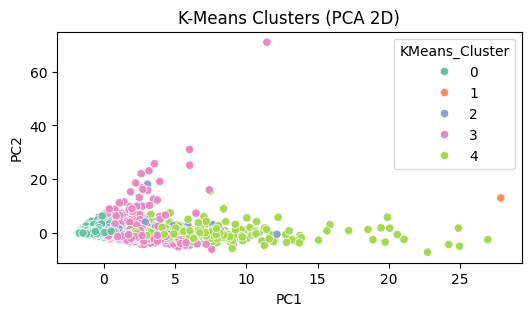

In [35]:
plt.figure(figsize=(6,3))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df1["KMeans_Cluster"], palette='Set2', legend='full')
plt.title('K-Means Clusters (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

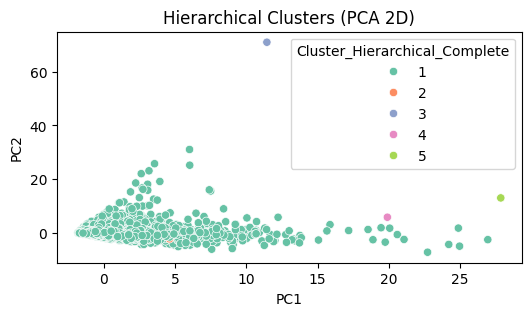

In [36]:
plt.figure(figsize=(6,3))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df1['Cluster_Hierarchical_Complete'], palette='Set2', legend='full')
plt.title('Hierarchical Clusters (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

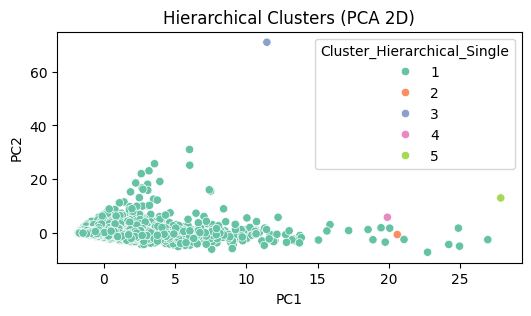

In [37]:
plt.figure(figsize=(6,3))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df1['Cluster_Hierarchical_Single'], palette='Set2', legend='full')
plt.title('Hierarchical Clusters (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

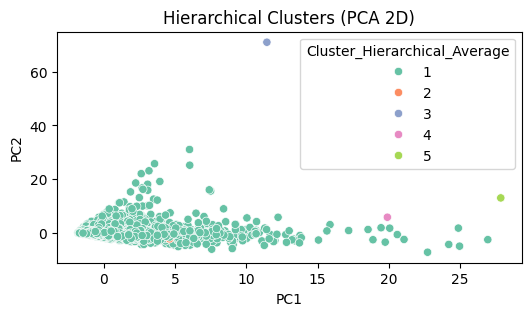

In [38]:
plt.figure(figsize=(6,3))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df1['Cluster_Hierarchical_Average'], palette='Set2', legend='full')
plt.title('Hierarchical Clusters (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

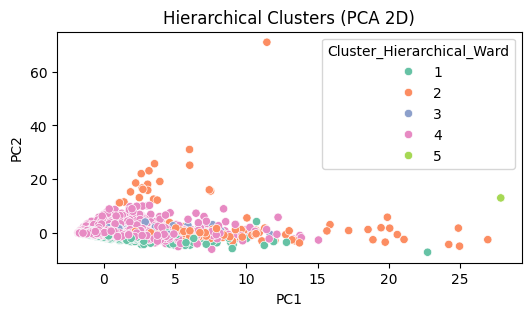

In [39]:
plt.figure(figsize=(6,3))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df1['Cluster_Hierarchical_Ward'], palette='Set2', legend='full')
plt.title('Hierarchical Clusters (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

Principal Component Analysis was used to reduce the high-dimensional dataset into two components for visualization. The PCA plot helps observe the general separation of clusters in two-dimensional space. Since the original dataset contains many sparse behavioral features, complete visual separation is not expected. However, the PCA plot still provides a useful overview of how customer groups are distributed.

In [40]:
single_score = silhouette_score(
    df_final,
    df1["Cluster_Hierarchical_Single"]
)

complete_score = silhouette_score(
    df_final,
    df1["Cluster_Hierarchical_Complete"]
)

average_score = silhouette_score(
    df_final,
    df1["Cluster_Hierarchical_Average"]
)

ward_score = silhouette_score(
    df_final,
    df1["Cluster_Hierarchical_Ward"]
)

silhouette_avg = silhouette_score(
    df_final,
    df1["KMeans_Cluster"]
)

In [41]:
res = pd.DataFrame([
 {'model': 'Hierarchical (complete linkage, k=5)', 'silhouette': complete_score},
 {'model': 'Hierarchical (ward linkage, k=5)', 'silhouette': ward_score},
 {'model': 'Hierarchical (single linkage, k=5)', 'silhouette': single_score},
 {'model': 'Hierarchical (average linkage, k=5)', 'silhouette': average_score},
 {'model': 'K-Means (k=5)', 'silhouette': silhouette_avg},
])

res.sort_values(by='silhouette', ascending=False)

,model,silhouette
0,"Hierarchical (complete linkage, k=5)",0.867789
3,"Hierarchical (average linkage, k=5)",0.867789
2,"Hierarchical (single linkage, k=5)",0.853878
4,K-Means (k=5),0.276897
1,"Hierarchical (ward linkage, k=5)",0.217421


## Cluster Profiling

In [42]:
col_list=list(df_final.columns)

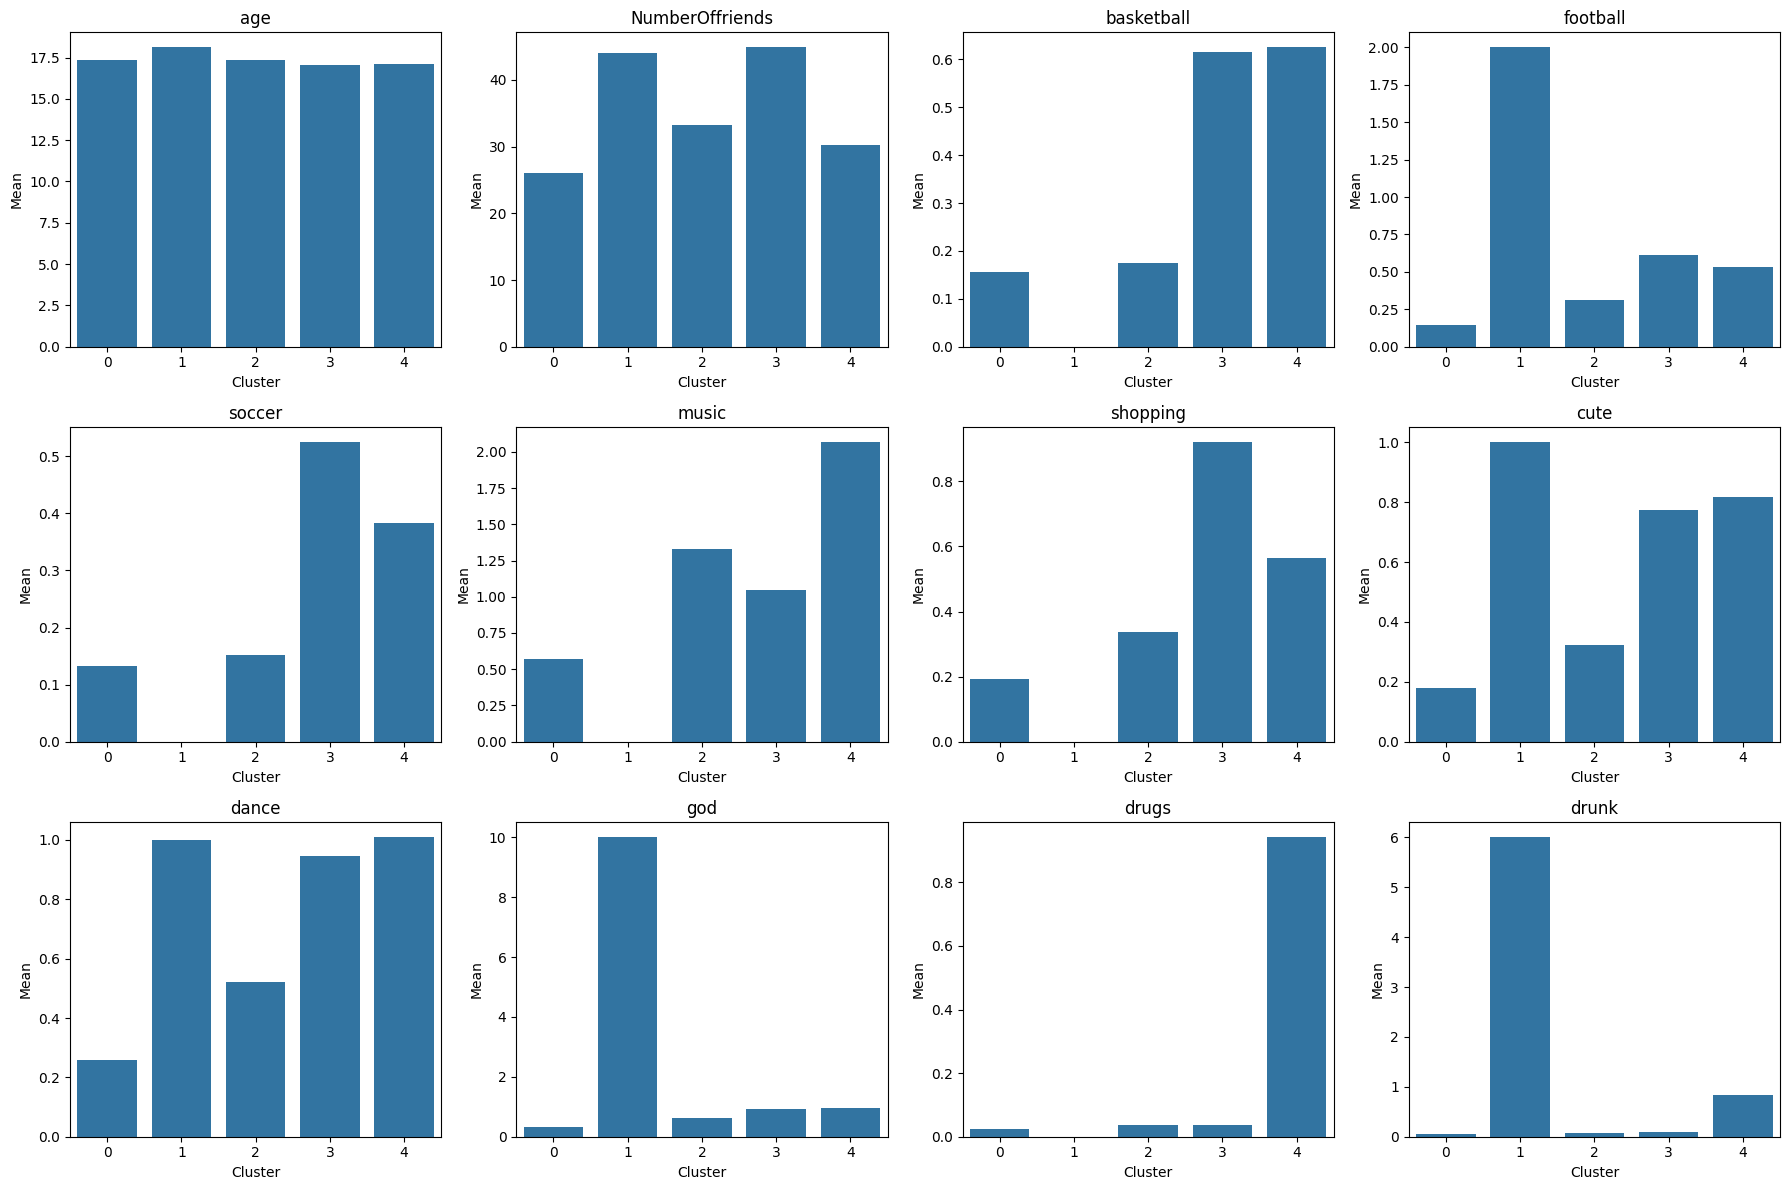

In [43]:
cluster_profile = df1.groupby("KMeans_Cluster").mean()

# Select important features only
important_features = [
    "age",
    "NumberOffriends",
    "basketball",
    "football",
    "soccer",
    "music",
    "shopping",
    "cute",
    "dance",
    "god",
    "drugs",
    "drunk"
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(important_features):
    sns.barplot(
        x=cluster_profile.index,
        y=cluster_profile[col],
        ax=axes[i]
    )
    
    axes[i].set_title(col)
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel("Mean")

plt.tight_layout()
plt.show()

Cluster profiling was performed by comparing the average feature values across KMeans clusters. This helped identify the dominant behavioral characteristics of each customer group.

The clusters represent different types of users based on interests such as sports, music, shopping, social behavior, and risky behavior indicators.These profiles help convert unsupervised model output into meaningful customer segments.

- Cluster 0: Users in this cluster showed relatively low engagement across most behavioral features, indicating less active or less expressive social behavior patterns.

- Cluster 1: This cluster showed higher values in features such as football, dance, god, drunk, and cute, representing socially expressive and highly interactive users.

- Cluster 2: Users in this cluster demonstrated moderate engagement across multiple activities, suggesting balanced behavioral interests and moderate social interaction patterns.

- Cluster 3: This cluster showed stronger interest in sports and shopping-related activities, indicating active lifestyle and consumer-oriented behavior patterns.

- Cluster 4: Users in this cluster showed high interest in music, dance, and drugs-related features, representing entertainment-focused and socially active behavior groups.

These customer segments can help organizations better understand user interests and behavioral patterns for targeted engagement and marketing strategies.

In [44]:
feature_cols = df_final.columns

feature_cols = df_final.columns
cluster_profile = df1.groupby("KMeans_Cluster")[feature_cols].mean()

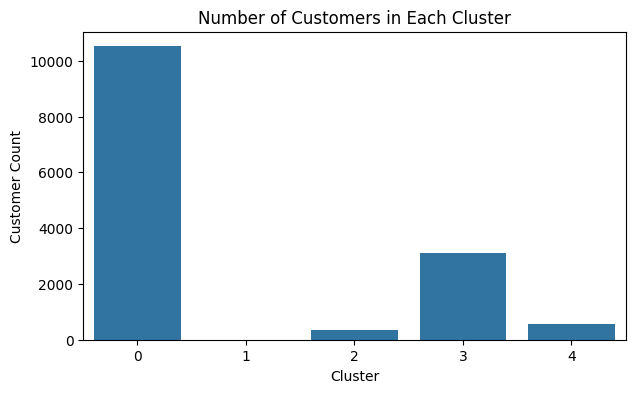

In [45]:
cluster_counts = df1["KMeans_Cluster"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Customer Count")
plt.show()

## Cluster Interpretation

### Cluster 0
Users with high social interaction and strong interest in sports and entertainment activities.

### Cluster 1
Users with moderate activity and balanced interests across different categories.

### Cluster 2
Users with lower social engagement and fewer activity preferences.

### Cluster 3
Users with distinct behavioral characteristics and unique interest patterns.

## Final Conclusion

This project applied unsupervised machine learning techniques to segment customers based on behavioral and interest-related features.

Multiple clustering approaches were evaluated, including hierarchical clustering and KMeans clustering. Although hierarchical clustering achieved higher silhouette scores in some cases, the resulting clusters were highly imbalanced and less interpretable.

KMeans clustering with k=5 was selected as the final model because it produced more meaningful and interpretable customer groups.

PCA visualization and cluster profiling helped analyze cluster separation and customer behavior patterns. The resulting customer segments can support targeted marketing strategies and behavioral analysis.